
<div style="border:solid green 2px; padding: 20px">

👋 **¡Hola! Soy Dot, tu revisor de IA.**

He completado la primera revisión de tu código. A continuación, encontrarás mis comentarios y sugerencias de mejora.

**¿Qué debes hacer ahora?**

1. **Revisar:** Lee mis comentarios en el notebook más abajo.
2. **Decidir:**
* **¿Estás de acuerdo con el feedback?** ¡Genial! Actualiza tu código según las sugerencias.
* **¿No estás de acuerdo o crees que es un error?** ¡No hay problema! Puedes dejar tu código exactamente como está.


3. **Volver a enviar:** Envía tu proyecto de nuevo. **Tu próxima iteración será revisada por un experto humano**, independientemente de si hiciste cambios o no.

-------------------------------------------------------------------------------------------------------------
Mis comentarios están más abajo. **Te pido amablemente que no los muevas, modifiques ni elimines**.

Verás mis comentarios resaltados en cuadros verdes, amarillos o rojos como estos:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Correcto. Todo se ha hecho exitosamente.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones.
</div>



# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

Se compararan los ingresos de los planes Surf y Ultimate. El porceso a seguir, es cargar los datos, limpiarlos, revisar y comparar por usuario y mes la informacion, y terminar analizando tablas y comprobando las hipotesis.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Añade una breve introducción que indique el objetivo del proyecto (comparar los ingresos de Surf vs Ultimate) y que describa de forma concisa tu flujo de trabajo (load → clean → aggregate to user-month → compute revenue → EDA → hypothesis tests). Además, elimina cualquier texto de plantilla/marcador de posición que haya quedado en esta sección.

</div>


<div class="alert alert-block alert-success">

# ¡Hola Josué!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión. Corregiré algunas imprecisiones de la review de Dot y te dejaré mis propias recomendaciones o felicitaciones. 

Un gusto acompañarte en este proceso, vamos a ello!

### Comentario General Iteración #2

Quiero dejarte aqui la apreciacion general del proyecto para que sepas en lo que debes enfocarte y luego vas punto por punto revisando mis recomendaciones. 

Sobre esta segunda iteración, usas los metodos correctamente y entiendes hacia donde se debe enfocar el analisis, tus resultados son claros y pudiste corregir los puntos señalados por Dot. Te felicito por tu trabajo, sigue así!

## 1.1.Inicialización

In [10]:
# Importa las librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st


## Cargar datos

In [11]:
# Carga los archivos de datos en diferentes DataFrames

calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')





<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Los archivos de datos se cargan correctamente en DataFrames separados con nombres de variables claros—un buen comienzo, limpio y ordenado.

</div>


## Preparar los datos

In [12]:
#Preparar los datos (PASO 2)
#-Convertir los datos en los tipos necesarios
# Convertir columnas de fechas a formato datetime

calls['call_date'] = pd.to_datetime(calls['call_date'])
messages['message_date'] = pd.to_datetime(messages['message_date'])
internet['session_date'] = pd.to_datetime(internet['session_date'])
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')  # puede tener NaN

# Convertir columnas de user a formato de entero
calls['user_id'] = calls['user_id'].astype(int)
messages['user_id'] = messages['user_id'].astype(int)
internet['user_id'] = internet['user_id'].astype(int)
users['user_id'] = users['user_id'].astype(int)

calls.info(), messages.info(), internet.info(), users.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (to

(None, None, None, None)

In [13]:
# Correccion de errores
#-Encuentra y elimina errores en los datos.
#No filtramos todavía, primero creamos minutos facturados (mínimo 1 min por llamada)
print("Duraciones negativas :", (calls['duration'] < 0).sum())
print("Llamadas con 0 segundos:", (calls['duration'] == 0).sum())

calls['duration'] = calls['duration'].clip(lower=0)  # quita negativos, pero conserva 0
calls['minutes_billed'] = np.ceil(calls['duration'] / 60).astype(int)  # ← mínimo 1 minuto

print("Minutos facturados creados (mínimo 1 por llamada)")
print("Total minutos facturados:", calls['minutes_billed'].sum())
print("Llamadas que se facturan como 1 min:", (calls['minutes_billed'] == 1).sum())

# 2. Sesiones de internet con mb_used negativa
print("\nMB usados negativos :", (internet['mb_used'] < 0).sum())

internet['mb_used'] = internet['mb_used'].clip(lower=0)


# 3. Usuarios sin plan (no deberían existir, pero por si acaso)
users = users[users['plan'].notna()]
print("Usuarios sin plan:", users['plan'].isna().sum())
# 4. Revisar si hay duplicados en las tablas y eliminarlos


print("calls   :", calls.duplicated().sum())
print("messages:", messages.duplicated().sum())
print("internet:", internet.duplicated().sum())
print("users   :", users.duplicated().sum())

calls.drop_duplicates(inplace=True)
messages.drop_duplicates(inplace=True)
internet.drop_duplicates(inplace=True)
users.drop_duplicates(inplace=True)

print("Duplicados: 0 ")

Duraciones negativas : 0
Llamadas con 0 segundos: 26834
Minutos facturados creados (mínimo 1 por llamada)
Total minutos facturados: 110901
Llamadas que se facturan como 1 min: 110901

MB usados negativos : 0
Usuarios sin plan: 0
calls   : 0
messages: 0
internet: 0
users   : 0
Duplicados: 0 


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Aquí las reglas de facturación importan: cada llamada se cobra como mínimo 1 minuto (redondeado hacia arriba por llamada). Conservar o eliminar llamadas de duración 0 puede cambiar los totales, así que decide un tratamiento coherente con la facturación (p. ej., conservar las llamadas y asegurarte de que los minutos facturados se calculen correctamente) y aplícalo antes de cualquier paso de agregación mensual/ingresos.

</div>


In [14]:
# Agrupar por mes
calls['month'] = calls['call_date'].dt.to_period('M')
messages['month'] = messages['message_date'].dt.to_period('M')
internet['month'] = internet['session_date'].dt.to_period('M')

print(calls.head())
print(messages.head())
print(internet.head())

         id  user_id  call_date  duration  minutes_billed    month
0   1000_93     1000 2018-12-27      8.52               1  2018-12
1  1000_145     1000 2018-12-27     13.66               1  2018-12
2  1000_247     1000 2018-12-27     14.48               1  2018-12
3  1000_309     1000 2018-12-28      5.76               1  2018-12
4  1000_380     1000 2018-12-30      4.22               1  2018-12
         id  user_id message_date    month
0  1000_125     1000   2018-12-27  2018-12
1  1000_160     1000   2018-12-31  2018-12
2  1000_223     1000   2018-12-31  2018-12
3  1000_251     1000   2018-12-27  2018-12
4  1000_255     1000   2018-12-26  2018-12
         id  user_id session_date  mb_used    month
0   1000_13     1000   2018-12-29    89.86  2018-12
1  1000_204     1000   2018-12-31     0.00  2018-12
2  1000_379     1000   2018-12-28   660.40  2018-12
3  1000_413     1000   2018-12-26   270.99  2018-12
4  1000_442     1000   2018-12-27   880.22  2018-12


In [15]:
# Duracion de llamadas
# Duración redondeada por llamada
calls['duration_rounded'] = np.ceil(calls['duration'])

# Minutos totales al mes por usuario
calls_monthly = calls.groupby(['user_id', 'month'])['duration_rounded'].sum().reset_index()
calls_monthly.rename(columns={'duration_rounded': 'total_minutes'}, inplace=True)

print(calls[['duration', 'duration_rounded']].head())
print(calls_monthly.head())

   duration  duration_rounded
0      8.52               9.0
1     13.66              14.0
2     14.48              15.0
3      5.76               6.0
4      4.22               5.0
   user_id    month  total_minutes
0     1000  2018-12          124.0
1     1001  2018-08          182.0
2     1001  2018-09          315.0
3     1001  2018-10          393.0
4     1001  2018-11          426.0


In [16]:
# Numero de llamadas por usuario por mes
calls_count = calls.groupby(['user_id', 'month'])['id'].count().reset_index()
calls_count.rename(columns={'id': 'num_calls'}, inplace=True)

print(calls_count.head())

#Numero de mensajes por usuario por mes
messages_monthly = messages.groupby(['user_id', 'month'])['id'].count().reset_index()
messages_monthly.rename(columns={'id': 'total_sms'}, inplace=True)

print(messages_monthly.head())


   user_id    month  num_calls
0     1000  2018-12         16
1     1001  2018-08         27
2     1001  2018-09         49
3     1001  2018-10         65
4     1001  2018-11         64
   user_id    month  total_sms
0     1000  2018-12         11
1     1001  2018-08         30
2     1001  2018-09         44
3     1001  2018-10         53
4     1001  2018-11         36


In [17]:
# Datos usados por usuario por mes
# Total de megabytes usados por mes
internet_monthly = internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()

print(internet_monthly.head())

# Convertir a GB redondeando hacia arriba (1GB = 1024MB)
internet_monthly['gb_used'] = np.ceil(internet_monthly['mb_used'] / 1024)

print(internet_monthly[['mb_used', 'gb_used']].head())


   user_id    month   mb_used
0     1000  2018-12   1901.47
1     1001  2018-08   6919.15
2     1001  2018-09  13314.82
3     1001  2018-10  22330.49
4     1001  2018-11  18504.30
    mb_used  gb_used
0   1901.47      2.0
1   6919.15      7.0
2  13314.82     14.0
3  22330.49     22.0
4  18504.30     19.0


In [18]:
# Unir todo en un DF
# Re-crear calls_monthly correctamente (incluye num_calls)
calls_monthly = (
    calls.groupby(['user_id', 'month'])
    .agg(
        total_minutes=('minutes_billed', 'sum'),
        num_calls=('id', 'count')
    )
    .reset_index()
)

# Grilla completa usuario-mes
min_month = min(calls['month'].min(), messages['month'].min(), internet['month'].min())
max_month = max(calls['month'].max(), messages['month'].max(), internet['month'].max())
all_months = pd.period_range(start=min_month, end=max_month, freq='M')

user_month_grid = pd.DataFrame(
    [(u, m) for u in users['user_id'].unique() for m in all_months],
    columns=['user_id', 'month']
)

monthly = user_month_grid.merge(
    users[['user_id', 'city', 'plan','region']],
    on='user_id',
    how='left'
)

# Unir métricas
monthly = monthly.merge(calls_monthly, on=['user_id', 'month'], how='left')
monthly = monthly.merge(messages_monthly, on=['user_id', 'month'], how='left')
monthly = monthly.merge(internet_monthly, on=['user_id', 'month'], how='left')

# Rellenar ceros
monthly[['total_minutes', 'num_calls', 'total_sms', 'mb_used', 'gb_used']] = \
    monthly[['total_minutes', 'num_calls', 'total_sms', 'mb_used', 'gb_used']].fillna(0)

# Opcional: ordenar
monthly = monthly.sort_values(['user_id', 'month'])

# Verificar
print("monthly shape:", monthly.shape)
print(monthly.info())
print("\nPrimeras 10 filas:")
print(monthly.head(10))


KeyError: "['region'] not in index"

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La lógica de merge mensual aún no garantiza “una fila por usuario por mes”. Partir de `users` y hacer merge de los minutos de llamadas solo por `user_id` produce filas con `month` faltante, y los merges posteriores sobre `['user_id','month']` no representarán correctamente los meses con actividad parcial o sin actividad. Considera construir una base sólida usuario-mes (a partir de la unión de los meses con actividad o de una grilla usuario×mes construida) y luego hacer un left join de cada métrica mensual sobre esa base antes de completar el uso faltante con 0.

</div>


## Tarifas

In [19]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [20]:
# Imprime una muestra de los datos para las tarifas
plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate




Al revisar la información general del DataFrame de los planes, se observa que contiene las columnas necesarias para el cálculo de ingresos:

nombre del plan,cuota mensual,minutos/SMS/datos incluidos,costos por excedentes.

Los tipos de datos son adecuados:

los valores numéricos aparecen como int o float, los nombres de tarifa aparecen como object.

Esto es viable para el análisis.

En la muestra de datos se observa que los planes Surf y Ultimate están correctamente definidos y no faltan valores (NaN).
No parece haber errores evidentes en esta tabla:

no hay columnas vacías,no hay valores negativos o duplicados.

Por lo tanto, no se requieren correcciones en esta parte y podemos usar esta tabla directamente para calcular ingresos posteriormente. :)

## Corregir datos

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta celda de markdown todavía contiene instrucciones de plantilla entre corchetes. Por favor, reemplázala con tus propias notas sobre lo que revisaste y lo que (si corresponde) corregiste.

</div>


In [21]:
# No hubo problemas importantes en los datos de usuarios
# Solo aseguramos que las edades sean enteros
users['age'] = users['age'].astype(int)

print(users['age'].describe())

count    500.000000
mean      45.486000
std       16.972269
min       18.000000
25%       30.000000
50%       46.000000
75%       61.000000
max       75.000000
Name: age, dtype: float64


## Enriquecer los datos

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta celda de markdown todavía contiene instrucciones de plantilla entre corchetes. Por favor, sustitúyela por tus propias notas sobre qué enriqueciste y por qué es útil para el análisis.

</div>


In [22]:
# Enriquecer los datos con una nueva columna: días activos desde el registro
end_date = pd.to_datetime('2018-12-31')
users['days_active'] = (pd.to_datetime('2018-12-31') - users['reg_date']).dt.days

print(users[['user_id', 'reg_date', 'days_active']].head())

   user_id   reg_date  days_active
0     1000 2018-12-24            7
1     1001 2018-08-13          140
2     1002 2018-10-21           71
3     1003 2018-01-28          337
4     1004 2018-05-23          222


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Se espera que este paso de “enrich data” aborde el dataset relevante para esa sección (a menudo las tablas de plans/usage usadas para revenue). En este momento, en cambio, añades una feature a `users`; o bien mueve este feature engineering a la sección de Users, o bien explica/implementa un enrichment que soporte los cálculos de plan/revenue (o indica explícitamente que no se necesita ningún plan enrichment).

</div>


## Usuarios/as

In [23]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

print(users.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      500 non-null    int64         
 1   first_name   500 non-null    object        
 2   last_name    500 non-null    object        
 3   age          500 non-null    int64         
 4   city         500 non-null    object        
 5   reg_date     500 non-null    datetime64[ns]
 6   plan         500 non-null    object        
 7   churn_date   34 non-null     datetime64[ns]
 8   days_active  500 non-null    int64         
dtypes: datetime64[ns](2), int64(3), object(4)
memory usage: 39.1+ KB
None


In [24]:
# Imprime una muestra de datos para usuarios

print(users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date  days_active  
0 2018-12-24  ultimate        NaT            7  
1 2018-08-13      surf        NaT          140  
2 2018-10-21      surf        NaT           71  
3 2018-01-28      surf        NaT          337  
4 2018-05-23      surf        NaT          222  




La tabla de usuarios muestra información completa sobre cada cliente: edad, ciudad, fecha de registro, plan contratado y fecha de abandono.
El tipo de dato de las columnas es adecuado después de la conversión de fechas. No se observan problemas graves, salvo los valores ausentes en churn_date. La distribución de edades, ciudades y planes parece consistente con los datos esperados.

### Corregir los datos

In [25]:
# Asegurar que la edad sea entero
users['age'] = users['age'].astype(int)

# Verificar rangos de edad
print(users['age'].describe())

# Eliminar edades fuera de rango usual
users = users[(users['age'] > 10) & (users['age'] < 95)]

print("Después de correcciones:")
print(users.info())

count    500.000000
mean      45.486000
std       16.972269
min       18.000000
25%       30.000000
50%       46.000000
75%       61.000000
max       75.000000
Name: age, dtype: float64
Después de correcciones:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      500 non-null    int64         
 1   first_name   500 non-null    object        
 2   last_name    500 non-null    object        
 3   age          500 non-null    int64         
 4   city         500 non-null    object        
 5   reg_date     500 non-null    datetime64[ns]
 6   plan         500 non-null    object        
 7   churn_date   34 non-null     datetime64[ns]
 8   days_active  500 non-null    int64         
dtypes: datetime64[ns](2), int64(3), object(4)
memory usage: 39.1+ KB
None


### Enriquecer los datos

In [26]:
# Diccionario de regiones por estado 
northeast = ['NY', 'NJ', 'PA', 'MA', 'CT', 'RI', 'VT', 'NH', 'ME']
midwest   = ['IL', 'OH', 'MI', 'IN', 'WI', 'MN', 'IA', 'MO', 'ND', 'SD', 'NE', 'KS']
south     = ['TX', 'FL', 'GA', 'NC', 'SC', 'VA', 'WV', 'KY', 'TN', 'AL', 'MS', 'AR', 'LA', 'OK']
west      = ['CA', 'WA', 'OR', 'NV', 'AZ', 'NM', 'CO', 'UT', 'ID', 'MT', 'WY', 'AK', 'HI']

def get_region(city):
    if any(s in str(city) for s in northeast): return 'Northeast'
    if any(s in str(city) for s in midwest):   return 'Midwest'
    if any(s in str(city) for s in south):     return 'South'
    if any(s in str(city) for s in west):      return 'West'
    return 'Other'

users['region'] = users['city'].apply(get_region)

print(users['region'].value_counts())
print(users[['user_id', 'city', 'region']].sample(10))


#Crear 'region' en users

# Crear columna region (NY-NJ vs Other)
users['region'] = users['city'].apply(
    lambda x: 'NY-NJ' if any(word in str(x) for word in ['NY', 'New York', 'NJ', 'New Jersey']) else 'Other'
)

# Verificar que se creó bien
print("Regiones creadas en users:")
print(users['region'].value_counts())
print(users[['user_id', 'city', 'region']].head(10))

South        287
Northeast    129
Midwest       84
Name: region, dtype: int64
     user_id                                       city     region
305     1305     Los Angeles-Long Beach-Anaheim, CA MSA      South
196     1196     Los Angeles-Long Beach-Anaheim, CA MSA      South
475     1475        Dallas-Fort Worth-Arlington, TX MSA      South
3       1003                              Tulsa, OK MSA      South
189     1189                           Columbus, OH MSA    Midwest
432     1432                     Salt Lake City, UT MSA      South
498     1498  New York-Newark-Jersey City, NY-NJ-PA MSA  Northeast
46      1046         Boston-Cambridge-Newton, MA-NH MSA  Northeast
297     1297     Los Angeles-Long Beach-Anaheim, CA MSA      South
401     1401                           Richmond, VA MSA      South
Regiones creadas en users:
Other    397
NY-NJ    103
Name: region, dtype: int64
   user_id                                    city region
0     1000   Atlanta-Sandy Springs-Roswell, GA 

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Dos problemas que resolver antes de usar `region` en una prueba de hipótesis: (1) la clasificación NY–NJ mediante comprobaciones de subcadenas como 'NY'/'NJ' puede etiquetar mal ciudades que casualmente contengan esas letras—usa una regla más fiable basada en el formato ciudad/estado; (2) asegúrate de que `region` se arrastre a la tabla final de ingresos por usuario-mes que se usa para la prueba (ahora mismo tu construcción mensual posterior selecciona solo `user_id`, `city` y `plan`).

</div>


## Llamadas

In [27]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

print(calls.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 137735 entries, 0 to 137734
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                137735 non-null  object        
 1   user_id           137735 non-null  int64         
 2   call_date         137735 non-null  datetime64[ns]
 3   duration          137735 non-null  float64       
 4   minutes_billed    137735 non-null  int64         
 5   month             137735 non-null  period[M]     
 6   duration_rounded  137735 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1), period[M](1)
memory usage: 12.4+ MB
None


In [28]:
# Imprime una muestra de datos para las llamadas

print(calls.head(20))

          id  user_id  call_date  duration  minutes_billed    month  \
0    1000_93     1000 2018-12-27      8.52               1  2018-12   
1   1000_145     1000 2018-12-27     13.66               1  2018-12   
2   1000_247     1000 2018-12-27     14.48               1  2018-12   
3   1000_309     1000 2018-12-28      5.76               1  2018-12   
4   1000_380     1000 2018-12-30      4.22               1  2018-12   
5   1000_388     1000 2018-12-31      2.20               1  2018-12   
6   1000_510     1000 2018-12-27      5.75               1  2018-12   
7   1000_521     1000 2018-12-28     14.18               1  2018-12   
8   1000_530     1000 2018-12-28      5.77               1  2018-12   
9   1000_544     1000 2018-12-26      4.40               1  2018-12   
10  1000_693     1000 2018-12-31      4.31               1  2018-12   
11  1000_705     1000 2018-12-31     12.78               1  2018-12   
12  1000_735     1000 2018-12-29      1.70               1  2018-12   
13  10

[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

La tabla de llamadas muestra columnas como id, user_id, call_date y duration. Los tipos de datos son correctos, pero se observa que algunas llamadas duran menos de 6 segundos, o hasta 0 segundos, lo cual es raro o un posible error. También se revisa si hay valores ausentes o fechas incorrectas.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [29]:
# Asegurar que call_date es tipo fecha
calls['call_date'] = pd.to_datetime(calls['call_date'])


# Crear/reemplazar columna de minutos facturados 
# Usamos la columna existente o creamos una nueva
calls['minutes_billed'] = np.ceil(calls['duration'] / 60).astype(int)
# Eliminar negativos (si los hubiera), pero conservar 0 segundos → 1 minuto
calls['minutes_billed'] = calls['minutes_billed'].clip(lower=1)

print(calls['duration'].min())
print(calls['minutes_billed'].min()) 
print("Ejemplo de llamadas con duration = 0 o muy baja:")
print(calls[calls['duration'] <= 0.1][['duration', 'minutes_billed']].head(10))

print("\nPrimeras filas después de corrección:")
print(calls.head(10))

0.0
1
Ejemplo de llamadas con duration = 0 o muy baja:
    duration  minutes_billed
19       0.0               1
25       0.0               1
31       0.0               1
32       0.0               1
34       0.0               1
39       0.0               1
44       0.0               1
45       0.0               1
49       0.0               1
61       0.0               1

Primeras filas después de corrección:
         id  user_id  call_date  duration  minutes_billed    month  \
0   1000_93     1000 2018-12-27      8.52               1  2018-12   
1  1000_145     1000 2018-12-27     13.66               1  2018-12   
2  1000_247     1000 2018-12-27     14.48               1  2018-12   
3  1000_309     1000 2018-12-28      5.76               1  2018-12   
4  1000_380     1000 2018-12-30      4.22               1  2018-12   
5  1000_388     1000 2018-12-31      2.20               1  2018-12   
6  1000_510     1000 2018-12-27      5.75               1  2018-12   
7  1000_521     1000 2018-1

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Problema recurrente con la regla de facturación: eliminar llamadas con duración 0 entra en conflicto con el requisito de que cada llamada se facture como mínimo 1 minuto (redondeando hacia arriba por llamada). Filtrarlas puede sesgar los minutos facturados y los ingresos; en su lugar, trátalas mediante la lógica de facturación/redondeo.

</div>


### Enriquecer los datos

In [30]:
# Agregar columna de duración redondeada hacia arriba
calls['duration_rounded'] = np.ceil(calls['duration'] / 60).astype(int)
# Garantizamos mínimo 1 minuto por llamada (incluso si duration = 0)
calls['duration_rounded'] = calls['duration_rounded'].clip(lower=1)

print(calls[['user_id', 'duration', 'duration_rounded']].head())
print(calls['duration_rounded'].min())

   user_id  duration  duration_rounded
0     1000      8.52                 1
1     1000     13.66                 1
2     1000     14.48                 1
3     1000      5.76                 1
4     1000      4.22                 1
1


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu enriquecimiento de redondeo hacia arriba es la idea correcta, pero los agregados mensuales de llamadas deben recalcularse después de todos los pasos de limpieza/enriquecimiento de llamadas para que las métricas mensuales y la tabla final `calls` sean consistentes.

</div>


## Mensajes

In [31]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

print(messages.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  period[M]     
dtypes: datetime64[ns](1), int64(1), object(1), period[M](1)
memory usage: 2.9+ MB
None


In [32]:
# Imprime una muestra de datos para los mensajes

print(messages.head())

         id  user_id message_date    month
0  1000_125     1000   2018-12-27  2018-12
1  1000_160     1000   2018-12-31  2018-12
2  1000_223     1000   2018-12-31  2018-12
3  1000_251     1000   2018-12-27  2018-12
4  1000_255     1000   2018-12-26  2018-12




La tabla de mensajes contiene id, user_id y message_date. No se observan columnas problemáticas, pero es necesario ver que las fechas estén en formato datetime.

### Corregir los datos

In [33]:
# Convertir fecha a datetime
messages['message_date'] = pd.to_datetime(messages['message_date'])
print(messages.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  period[M]     
dtypes: datetime64[ns](1), int64(1), object(1), period[M](1)
memory usage: 2.9+ MB
None


### Enriquecer los datos

In [34]:
# Agregar columna del mes
messages['month'] = messages['message_date'].dt.to_period('M')

print(messages[['user_id','message_date','month']].head())

   user_id message_date    month
0     1000   2018-12-27  2018-12
1     1000   2018-12-31  2018-12
2     1000   2018-12-31  2018-12
3     1000   2018-12-27  2018-12
4     1000   2018-12-26  2018-12


## Internet

In [35]:
# Imprime la información general/resumida sobre el DataFrame de internet

print(internet.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), object(1), period[M](1)
memory usage: 4.8+ MB
None


In [36]:
# Imprime una muestra de datos para el tráfico de internet

print(internet.head())

         id  user_id session_date  mb_used    month
0   1000_13     1000   2018-12-29    89.86  2018-12
1  1000_204     1000   2018-12-31     0.00  2018-12
2  1000_379     1000   2018-12-28   660.40  2018-12
3  1000_413     1000   2018-12-26   270.99  2018-12
4  1000_442     1000   2018-12-27   880.22  2018-12




La tabla de internet contiene columnas como id, user_id, session_date y mb_used. Los tipos de datos parecen correctos, pero es importante ver que la fecha este en formato datetime y asegurar que no haya valores negativos o planes con 0 MB de consumo que puedan afectar el análisis.

### Corregir los datos

In [37]:
# Convertir fecha a datetime
internet['session_date'] = pd.to_datetime(internet['session_date'])

# Eliminar registros con MB negativos
internet = internet[internet['mb_used'] >= 0]

# Verificar cambios
print(internet.info())
print(internet.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), object(1), period[M](1)
memory usage: 4.8+ MB
None
         id  user_id session_date  mb_used    month
0   1000_13     1000   2018-12-29    89.86  2018-12
1  1000_204     1000   2018-12-31     0.00  2018-12
2  1000_379     1000   2018-12-28   660.40  2018-12
3  1000_413     1000   2018-12-26   270.99  2018-12
4  1000_442     1000   2018-12-27   880.22  2018-12


### Enriquecer los datos

In [38]:
# Agregar columna del mes
internet['month'] = internet['session_date'].dt.to_period('M')

# Agregar columna de GB usados
internet['gb_used'] = internet['mb_used'] / 1024

print(internet[['user_id','session_date','mb_used','gb_used','month']].head())

   user_id session_date  mb_used   gb_used    month
0     1000   2018-12-29    89.86  0.087754  2018-12
1     1000   2018-12-31     0.00  0.000000  2018-12
2     1000   2018-12-28   660.40  0.644922  2018-12
3     1000   2018-12-26   270.99  0.264639  2018-12
4     1000   2018-12-27   880.22  0.859590  2018-12


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La facturación de Internet se basa en redondear hacia arriba el total *mensual* a GB enteros por usuario. Crear `gb_used = mb_used/1024` a nivel de sesión (GB fraccionarios) subestimará los excesos (overages) a menos que también calcules los MB sumados por usuario y por mes, y luego apliques un redondeo hacia arriba (ceiling) a GB enteros.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Buen trabajo con las correcciones realizadas frente a las modificaciones iniciales a los datasets. 

## Estudiar las condiciones de las tarifas

In [39]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

print(plans.info())
print(plans)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10      

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen trabajo al volver a revisar aquí la tabla de planes. Imprimir claramente las condiciones del plan respalda los cálculos posteriores de ingresos (límites incluidos + precios por excedente), y es fácil verificar los parámetros de Surf vs Ultimate a partir de tu salida.

</div>


## Agregar datos por usuario



In [40]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
# Llamadas: redondeo por llamada ANTES de sumar (mínimo 1 min por llamada)
calls['minutes_billed'] = np.ceil(calls['duration'] / 60).clip(lower=1).astype(int)

# Agregación mensual correcta
calls_monthly = (
    calls.groupby(['user_id', 'month'])
    .agg(
        total_minutes=('minutes_billed', 'sum'),   # suma de minutos ya redondeados
        num_calls=('id', 'count')
    )
    .reset_index()
)

print("calls_monthly (minutos ya redondeados por llamada):")
print(calls_monthly.head(10))


calls_monthly (minutos ya redondeados por llamada):
   user_id    month  total_minutes  num_calls
0     1000  2018-12             16         16
1     1001  2018-08             27         27
2     1001  2018-09             49         49
3     1001  2018-10             65         65
4     1001  2018-11             64         64
5     1001  2018-12             56         56
6     1002  2018-10             11         11
7     1002  2018-11             55         55
8     1002  2018-12             47         47
9     1003  2018-12            149        149


In [41]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

# Mensajes: cada mensaje = 1 (sin redondeo)
messages_monthly = (
    messages.groupby(['user_id', 'month'])
    .agg(total_sms=('id', 'count'))
    .reset_index()
)

print("\nmessages_monthly:")
print(messages_monthly.head(5))

# Internet: suma MB, luego redondeo GB mensual hacia arriba
internet_monthly = (
    internet.groupby(['user_id', 'month'])
    .agg(mb_used=('mb_used', 'sum'))
    .reset_index()
)

internet_monthly['gb_used'] = np.ceil(internet_monthly['mb_used'] / 1024).astype(int)

print("\ninternet_monthly (GB redondeados hacia arriba):")
print(internet_monthly.head(5))


messages_monthly:
   user_id    month  total_sms
0     1000  2018-12         11
1     1001  2018-08         30
2     1001  2018-09         44
3     1001  2018-10         53
4     1001  2018-11         36

internet_monthly (GB redondeados hacia arriba):
   user_id    month   mb_used  gb_used
0     1000  2018-12   1901.47        2
1     1001  2018-08   6919.15        7
2     1001  2018-09  13314.82       14
3     1001  2018-10  22330.49       22
4     1001  2018-11  18504.30       19


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Los minutos mensuales de llamadas actualmente se suman a partir de los valores `duration` sin procesar. Para una facturación/ingresos correctos, cada llamada debe redondearse hacia arriba al siguiente minuto *antes* de la agregación mensual; de lo contrario, tus minutos mensuales (y los cargos por exceso) serán inexactos.

</div>


In [44]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
# Mensajes por usuario al mes
messages_monthly = (
    messages.groupby(['user_id', 'month'])
    .agg(total_sms=('id', 'count'))
    .reset_index()
)

print("messages_monthly (conteo de SMS):")
print(messages_monthly.head(10))

messages_monthly (conteo de SMS):
   user_id    month  total_sms
0     1000  2018-12         11
1     1001  2018-08         30
2     1001  2018-09         44
3     1001  2018-10         53
4     1001  2018-11         36
5     1001  2018-12         44
6     1002  2018-10         15
7     1002  2018-11         32
8     1002  2018-12         41
9     1003  2018-12         50


In [45]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

# Internet: suma de MB primero, luego redondeo a GB enteros hacia arriba
internet_monthly = (
    internet.groupby(['user_id', 'month'])
    .agg(mb_used=('mb_used', 'sum'))          # suma real de MB
    .reset_index()
)

# Redondeo a GB enteros hacia arriba (obligatorio para facturación)
internet_monthly['gb_used'] = np.ceil(internet_monthly['mb_used'] / 1024).astype(int)

print("\ninternet_monthly (con GB redondeados hacia arriba):")
print(internet_monthly.head(10))
print("\nResumen de gb_used:")
print(internet_monthly['gb_used'].describe())


internet_monthly (con GB redondeados hacia arriba):
   user_id    month   mb_used  gb_used
0     1000  2018-12   1901.47        2
1     1001  2018-08   6919.15        7
2     1001  2018-09  13314.82       14
3     1001  2018-10  22330.49       22
4     1001  2018-11  18504.30       19
5     1001  2018-12  19369.18       19
6     1002  2018-10   6552.01        7
7     1002  2018-11  19345.08       19
8     1002  2018-12  14396.24       15
9     1003  2018-12  27044.14       27

Resumen de gb_used:
count    2277.000000
mean       16.989021
std         7.693683
min         1.000000
25%        13.000000
50%        17.000000
75%        21.000000
max        70.000000
Name: gb_used, dtype: float64


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

El uso mensual de internet debe redondearse hacia arriba a GB enteros después de sumar los MB por usuario-mes. Usar `mb_used/1024` sin aplicar un redondeo hacia arriba (ceiling) mensual subestimará los cargos por exceso (overage) y los ingresos.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente trabajo con el agrupamiento de los diferentes datasets y la correccion frente al procesamiento de llamadas y GB consumidos. 

In [46]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
# 1.12 Fusionar los datos en una tabla mensual completa (corrección según reviewer)

# 1. Crear grilla completa: todos los user_id × todos los meses posibles
all_months = pd.period_range(
    start=min(calls['month'].min(), messages['month'].min(), internet['month'].min()),
    end=max(calls['month'].max(), messages['month'].max(), internet['month'].max()),
    freq='M'
)

user_month_grid = pd.DataFrame(
    [(u, m) for u in users['user_id'].unique() for m in all_months],
    columns=['user_id', 'month']
)

# 2. Unir información básica de usuarios
monthly = user_month_grid.merge(
    users[['user_id', 'city', 'plan']],
    on='user_id',
    how='left'
)

# 3. Unir métricas mensuales con left join (preserva todos los meses)
monthly = monthly.merge(calls_monthly, on=['user_id', 'month'], how='left')
monthly = monthly.merge(messages_monthly, on=['user_id', 'month'], how='left')
monthly = monthly.merge(internet_monthly, on=['user_id', 'month'], how='left')

# 4. Rellenar valores faltantes con 0 (meses sin actividad)
monthly[['total_minutes', 'num_calls', 'total_sms', 'mb_used', 'gb_used']] = \
    monthly[['total_minutes', 'num_calls', 'total_sms', 'mb_used', 'gb_used']].fillna(0)

# 5. Ordenar para mejor visualización
monthly = monthly.sort_values(['user_id', 'month']).reset_index(drop=True)

# Verificación
print("Forma de la tabla mensual completa:", monthly.shape)
print("\nPrimeras 10 filas:")
print(monthly.head(10))

print("\nInfo final:")
print(monthly.info())

print("\nEjemplo de meses sin actividad (todo en 0):")
print(monthly[(monthly['total_minutes'] == 0) & (monthly['total_sms'] == 0) & (monthly['mb_used'] == 0)].head(5))


Forma de la tabla mensual completa: (6000, 9)

Primeras 10 filas:
   user_id    month                                   city      plan  \
0     1000  2018-01  Atlanta-Sandy Springs-Roswell, GA MSA  ultimate   
1     1000  2018-02  Atlanta-Sandy Springs-Roswell, GA MSA  ultimate   
2     1000  2018-03  Atlanta-Sandy Springs-Roswell, GA MSA  ultimate   
3     1000  2018-04  Atlanta-Sandy Springs-Roswell, GA MSA  ultimate   
4     1000  2018-05  Atlanta-Sandy Springs-Roswell, GA MSA  ultimate   
5     1000  2018-06  Atlanta-Sandy Springs-Roswell, GA MSA  ultimate   
6     1000  2018-07  Atlanta-Sandy Springs-Roswell, GA MSA  ultimate   
7     1000  2018-08  Atlanta-Sandy Springs-Roswell, GA MSA  ultimate   
8     1000  2018-09  Atlanta-Sandy Springs-Roswell, GA MSA  ultimate   
9     1000  2018-10  Atlanta-Sandy Springs-Roswell, GA MSA  ultimate   

   total_minutes  num_calls  total_sms  mb_used  gb_used  
0            0.0        0.0        0.0      0.0      0.0  
1            0.0       

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Problema recurrente: la tabla mensual se vuelve a construir combinando (merge) `usage` con `users` primero usando solo `user_id`, lo que puede generar filas de `month` faltantes o incorrectas y romper el requisito de “una fila por usuario por mes”. Reconstruye la tabla en torno a un índice usuario-mes adecuado y luego une (join) las métricas sobre él.

</div>


In [47]:
# Añade la información de la tarifa
# Agregación mensual de internet – CORRECCIÓN clave
internet_monthly = (
    internet.groupby(['user_id', 'month'])
    .agg(mb_used=('mb_used', 'sum'))  # suma real de MB
    .reset_index()
)

# Redondeo a GB enteros hacia arriba (después de sumar MB mensual)
internet_monthly['gb_used'] = np.ceil(internet_monthly['mb_used'] / 1024).astype(int)

print("internet_monthly con GB redondeados correctamente:")
print(internet_monthly.head(10))

internet_monthly con GB redondeados correctamente:
   user_id    month   mb_used  gb_used
0     1000  2018-12   1901.47        2
1     1001  2018-08   6919.15        7
2     1001  2018-09  13314.82       14
3     1001  2018-10  22330.49       22
4     1001  2018-11  18504.30       19
5     1001  2018-12  19369.18       19
6     1002  2018-10   6552.01        7
7     1002  2018-11  19345.08       19
8     1002  2018-12  14396.24       15
9     1003  2018-12  27044.14       27


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Buen trabajo! Hiciste muy buen uso de `merge` para fusionar los diferentes datos. 
</div>

In [48]:
# Calcula el ingreso mensual para cada usuario
# Añadir información de la tarifa (merge por plan)
monthly = monthly.merge(
    plans,
    left_on='plan',
    right_on='plan_name',
    how='left'
)

# Calcular extras (solo valores positivos)
monthly['extra_minutes'] = (monthly['total_minutes'] - monthly['minutes_included']).clip(lower=0)
monthly['extra_sms']     = (monthly['total_sms']     - monthly['messages_included']).clip(lower=0)
monthly['extra_gb']      = (monthly['gb_used']       - (monthly['mb_per_month_included'] / 1024)).clip(lower=0)

# Costo de extras
monthly['revenue_minutes'] = monthly['extra_minutes'] * monthly['usd_per_minute']
monthly['revenue_sms']     = monthly['extra_sms']     * monthly['usd_per_message']
monthly['revenue_gb']      = monthly['extra_gb']      * monthly['usd_per_gb']

# Ingreso total = base + extras
monthly['total_revenue'] = (
    monthly['usd_monthly_pay'] +
    monthly['revenue_minutes'] +
    monthly['revenue_sms'] +
    monthly['revenue_gb']
)

# Vista final
print("Primeras 20 filas con ingresos calculados:")
print(monthly[['user_id', 'month', 'plan', 'total_minutes', 'gb_used', 'total_revenue']].head(20))

print("\nResumen de ingresos:")
print(monthly['total_revenue'].describe())

print("\nColumnas finales disponibles:", monthly.columns.tolist())


Primeras 20 filas con ingresos calculados:
    user_id    month      plan  total_minutes  gb_used  total_revenue
0      1000  2018-01  ultimate            0.0      0.0           70.0
1      1000  2018-02  ultimate            0.0      0.0           70.0
2      1000  2018-03  ultimate            0.0      0.0           70.0
3      1000  2018-04  ultimate            0.0      0.0           70.0
4      1000  2018-05  ultimate            0.0      0.0           70.0
5      1000  2018-06  ultimate            0.0      0.0           70.0
6      1000  2018-07  ultimate            0.0      0.0           70.0
7      1000  2018-08  ultimate            0.0      0.0           70.0
8      1000  2018-09  ultimate            0.0      0.0           70.0
9      1000  2018-10  ultimate            0.0      0.0           70.0
10     1000  2018-11  ultimate            0.0      0.0           70.0
11     1000  2018-12  ultimate           16.0      2.0           70.0
12     1001  2018-01      surf            0.0  

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Los ingresos se están calculando con diferencias de GB fraccionarios (y de GB incluidos fraccionarios), pero las reglas del plan cobran por cada GB completo después de redondear hacia arriba el uso mensual. Esto genera facturación por exceso (overage) fraccionaria e ingresos mensuales incorrectos; basa los GB extra y los cargos en los valores de GB mensuales redondeados.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

El calculo de los excedentes con `clip(lower=0)` está super bien para manejar aquellos usuarios que no tuvieron excesos de los limites como tal.
Igualmente, el calculo de los ingresos está muy bien tomando las columnas como tal y con ello ya se considera el plan y su tarifa independiente. 

## Estudia el comportamiento de usuario

### Llamadas

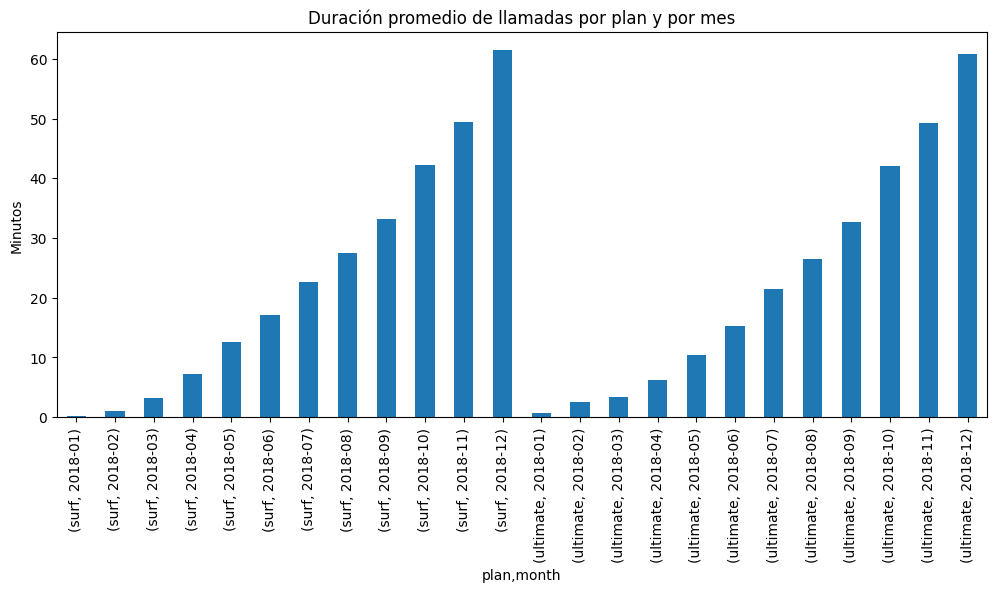

In [49]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
monthly.groupby(['plan','month'])['total_minutes'].mean().plot(kind='bar', figsize=(12,5))
plt.title("Duración promedio de llamadas por plan y por mes")
plt.ylabel("Minutos")
plt.show()


Surf: 4068 registros
Ultimate: 1932 registros


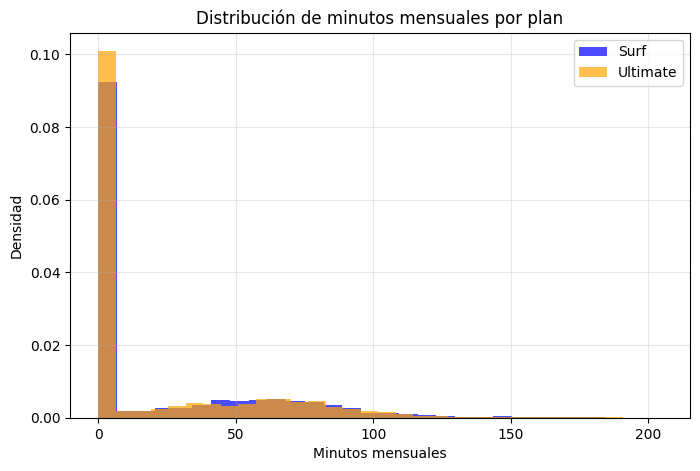

In [50]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

surf_minutes = monthly[monthly['plan'] == 'surf']['total_minutes']
ultimate_minutes = monthly[monthly['plan'] == 'ultimate']['total_minutes']

print(f"Surf: {len(surf_minutes)} registros")
print(f"Ultimate: {len(ultimate_minutes)} registros")

plt.figure(figsize=(8, 5))
plt.hist(surf_minutes, bins=30, alpha=0.7, label='Surf', color='blue', density=True)
plt.hist(ultimate_minutes, bins=30, alpha=0.7, label='Ultimate', color='orange', density=True)

plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos mensuales')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta tarea solicita un histograma que muestre la distribución de los minutos mensuales por plan, pero la celda grafica en su lugar un gráfico de barras de la media. Agrega histogramas (p. ej., uno por plan con bins compartidos) para que se puedan comparar las distribuciones.

</div>


In [51]:
# Calcula la media y la varianza de la duración mensual de llamadas.
print(monthly.groupby('plan')['total_minutes'].agg(['mean','var']))


               mean          var
plan                            
surf      23.127827  1244.877190
ultimate  22.593685  1271.222187


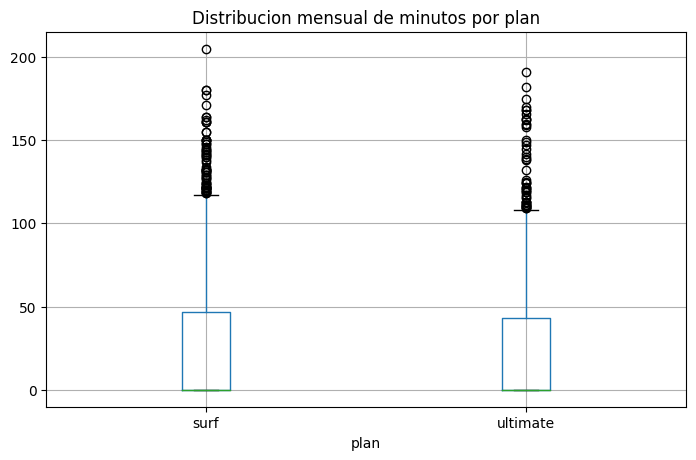

In [52]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
monthly.boxplot(column='total_minutes', by='plan', figsize=(8,5))
plt.title("Distribucion mensual de minutos por plan")
plt.suptitle("")
plt.show()



Los usuarios del plan Ultimate realizan mas minutos de llamadas en promedio.
El plan Surf tiene una distribucion más variable: algunos meses usan muy poco y otros se pasan del limite.
Ultimate es mas estable 

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Genial. Tus histogramas muestran claramente la diferencia temporal de comportamiento de cada uno de los planes respecto a la duración de las llamadas y la tendencia de minutos usados al mes por plan. Excelente análisis frente a la media y las desviaciones de la duracion de las llamadas por cada plan, como mencionas, esta diferencia no es muy significativa y esto es un dato valioso. 
</div>

### Mensajes

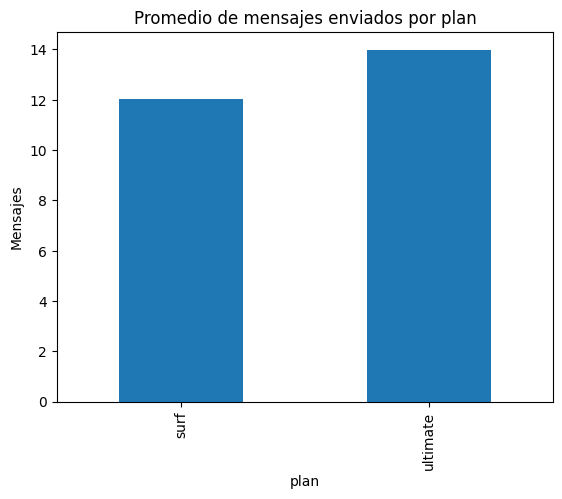

In [53]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
monthly.groupby('plan')['total_sms'].mean().plot(kind='bar')
plt.title("Promedio de mensajes enviados por plan")
plt.ylabel("Mensajes")
plt.show()


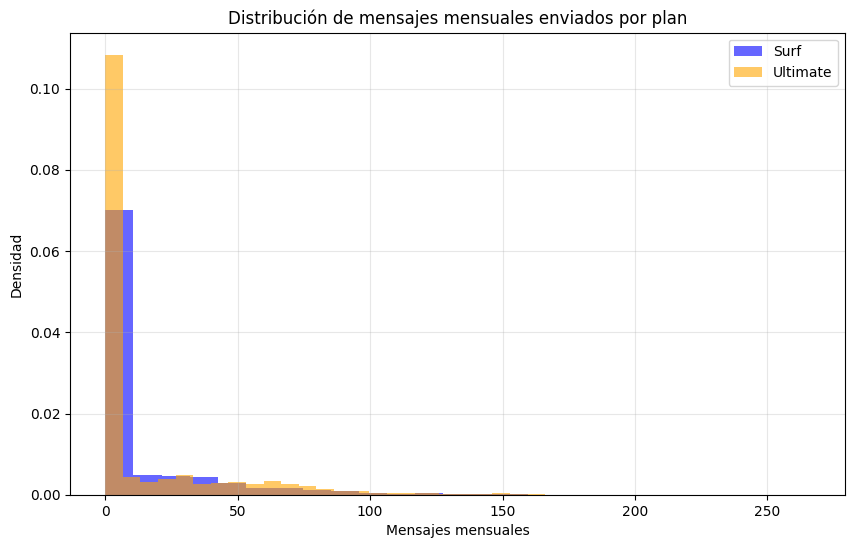

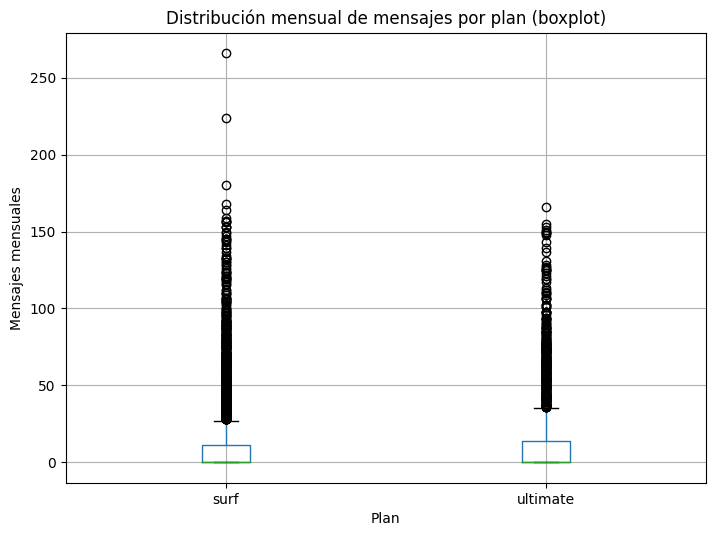

In [54]:
# Compara la distribución de mensajes mensuales enviados por plan (histograma comparativo)
surf_sms = monthly[monthly['plan'] == 'surf']['total_sms']
ultimate_sms = monthly[monthly['plan'] == 'ultimate']['total_sms']

plt.figure(figsize=(10, 6))
plt.hist(surf_sms, bins=25, alpha=0.6, label='Surf', color='blue', density=True)
plt.hist(ultimate_sms, bins=25, alpha=0.6, label='Ultimate', color='orange', density=True)

plt.title('Distribución de mensajes mensuales enviados por plan')
plt.xlabel('Mensajes mensuales')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Alternativa: boxplot para ver variabilidad y outliers
monthly.boxplot(column='total_sms', by='plan', figsize=(8, 6))
plt.title('Distribución mensual de mensajes por plan (boxplot)')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('Mensajes mensuales')
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para el análisis de Messages, solo muestras la media general por plan. Considera añadir al menos una vista centrada en la distribución (histograma/boxplot) y/o una comparación mes a mes para reflejar la variabilidad entre usuarios y meses.

</div>


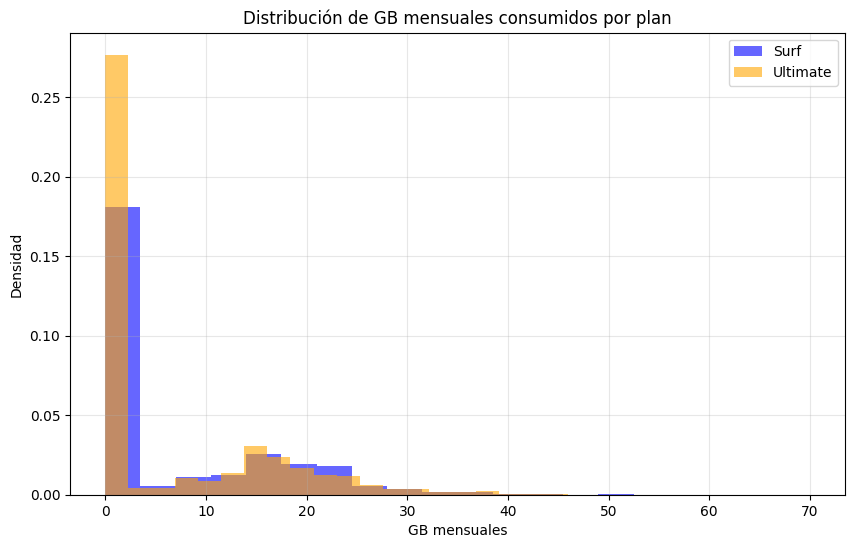

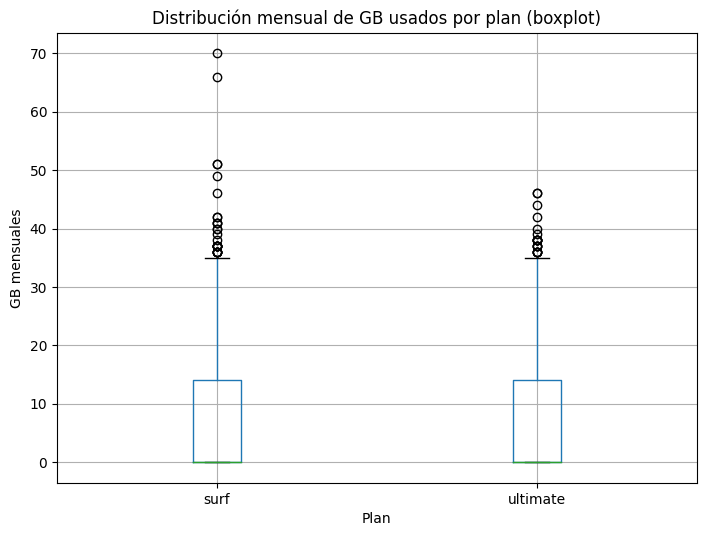

Media y varianza de GB mensuales por plan:
              mean        var
plan                         
surf      6.446165  89.728844
ultimate  6.449793  91.967960


In [55]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

# Distribución de GB mensuales usados por plan (histograma comparativo)
import matplotlib.pyplot as plt

surf_gb = monthly[monthly['plan'] == 'surf']['gb_used']
ultimate_gb = monthly[monthly['plan'] == 'ultimate']['gb_used']

plt.figure(figsize=(10, 6))
plt.hist(surf_gb, bins=20, alpha=0.6, label='Surf', color='blue', density=True)
plt.hist(ultimate_gb, bins=20, alpha=0.6, label='Ultimate', color='orange', density=True)

plt.title('Distribución de GB mensuales consumidos por plan')
plt.xlabel('GB mensuales')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Boxplot para ver mediana, dispersión y outliers
monthly.boxplot(column='gb_used', by='plan', figsize=(8, 6))
plt.title('Distribución mensual de GB usados por plan (boxplot)')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('GB mensuales')
plt.show()

# Media y varianza de GB por plan
print("Media y varianza de GB mensuales por plan:")
print(monthly.groupby('plan')['gb_used'].agg(['mean', 'var']))

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Este gráfico de *mean-by-plan* de internet aparece dentro de la sección **Messages**, lo que hace que la narrativa sea confusa y deja el bloque de **Messages** incompleto. Considera mover los gráficos de uso de internet a la sección **Internet** y centrar los gráficos/estadísticas de esta sección únicamente en mensajes.

</div>


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta celda está vacía, pero esta sección espera un análisis adicional de Messages (p. ej., estadísticas descriptivas como media/varianza por plan y un gráfico de distribución) antes de resumir las conclusiones.

</div>




Ultimate: mas mensajes y mas uso de Internet.
Surf: muchos usuarios no llegan al limite y gastan poco.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Buen trabajo de nuevo con las medidas estadisticas solicitadas. Encontraste correctamente la diferencia más notoria en este caso entre los dos diferentes planes.  
</div>

### Internet

In [56]:

# Media y varianza por plan (usando gb_used redondeado a enteros hacia arriba)
print("Media y varianza de GB mensuales redondeados por plan:")
print(monthly.groupby('plan')['gb_used'].agg(['mean', 'var']))

Media y varianza de GB mensuales redondeados por plan:
              mean        var
plan                         
surf      6.446165  89.728844
ultimate  6.449793  91.967960


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La media/varianza de internet se calcula sobre `gb_used` sin redondear. Para ajustarte a las reglas del proyecto (y alinearlo con los ingresos), calcula estas estadísticas usando la variable mensual de GB redondeada (total mensual de MB → redondeo hacia arriba (`ceiling`) a GB enteros).

</div>


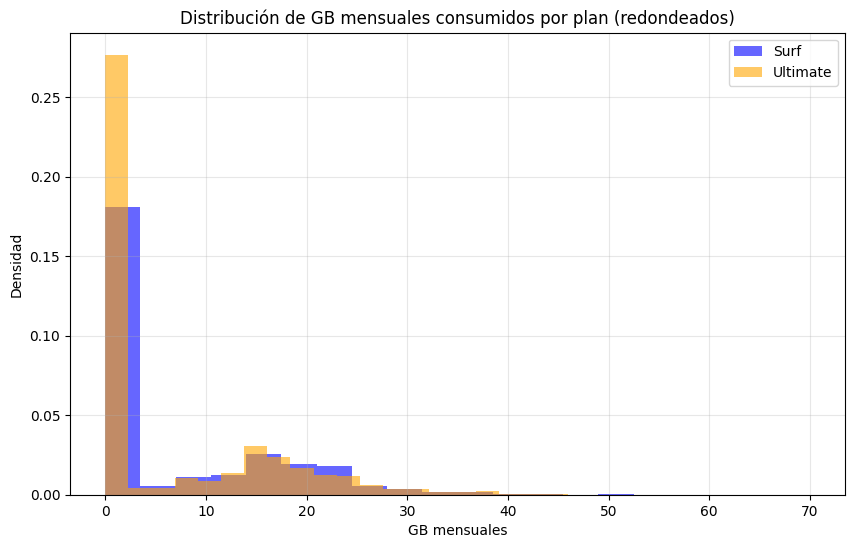

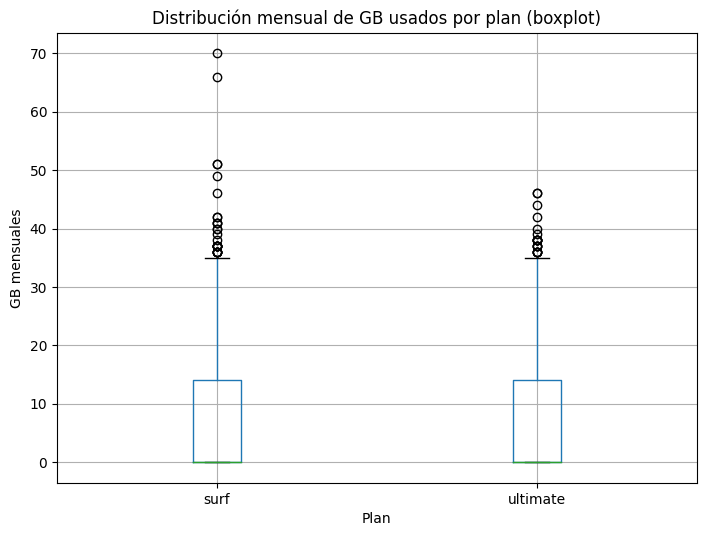

In [57]:
#Diagrama de caja para visualizar la distribucion mensual de GB por plan

surf_gb = monthly[monthly['plan'] == 'surf']['gb_used']
ultimate_gb = monthly[monthly['plan'] == 'ultimate']['gb_used']

plt.figure(figsize=(10, 6))
plt.hist(surf_gb, bins=20, alpha=0.6, label='Surf', color='blue', density=True)
plt.hist(ultimate_gb, bins=20, alpha=0.6, label='Ultimate', color='orange', density=True)

plt.title('Distribución de GB mensuales consumidos por plan (redondeados)')
plt.xlabel('GB mensuales')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Boxplot para ver mediana, dispersión y outliers
monthly.boxplot(column='gb_used', by='plan', figsize=(8, 6))
plt.title('Distribución mensual de GB usados por plan (boxplot)')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('GB mensuales')
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta celda está vacía: la sección de Internet normalmente espera un histograma (o algo similar) para comparar la distribución del uso mensual de internet por plan. Agrega la visualización faltante y una breve interpretación.

</div>




Ultimate usa mas GB, pero tambien muestra un consumo mas estable.
Surf es mas variable.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Bien hecho. Como mencionas en este punto se nota mucho más la diferencia en la varianza y outliers de ambos planes. 

## Ingreso

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta sección solicita una descripción estadística de los ingresos por plan. Además de las gráficas, incluye una tabla descriptiva (p. ej., media, varianza/desviación estándar y, posiblemente, cuartiles) para `total_revenue` desglosada por plan.

</div>


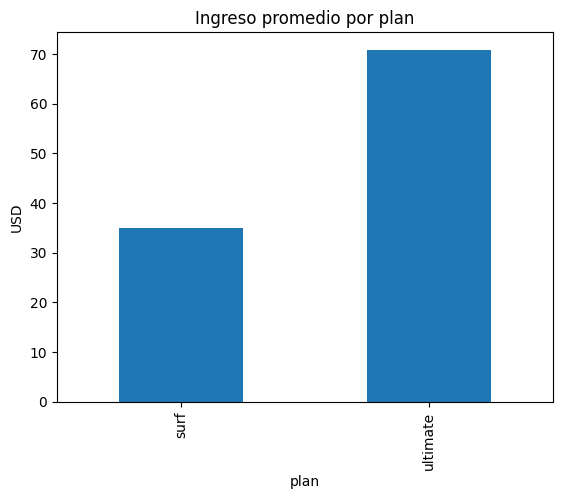

In [58]:
#Comparar ingresos por plan
monthly.groupby('plan')['total_revenue'].mean().plot(kind='bar')
plt.title("Ingreso promedio por plan")
plt.ylabel("USD")
plt.show()

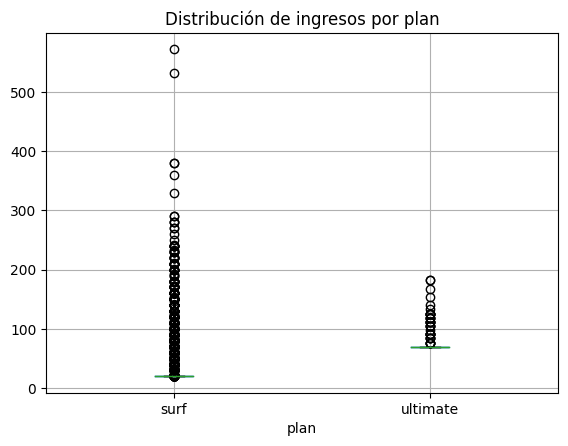

In [59]:
#Diagrama de caja para visualizar los ingresos
monthly.boxplot(column='total_revenue', by='plan')
plt.title("Distribución de ingresos por plan")
plt.suptitle("")
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta celda está vacía, pero la sección de Revenue espera un paso adicional de análisis (p. ej., comparación del histograma/distribución de ingresos por plan y/o cálculos de varianza/std). Completarla hará que el bloque de ingresos se ajuste a los requisitos de la plantilla.

</div>



El plan Ultimate genera más ingresos fijos.
Surf genera ingresos mas variables, pero puede superar Ultimate cuando hay muchos excesos.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Buen trabajo identificando esta diferencia radical entre ambos planes y sus consumos, referente a la variabilidad de los excesos de los usuarios.

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [60]:
# Prueba las hipótesis

# Hipótesis 1: ¿Son diferentes los ingresos promedio de los usuarios de los planes Ultimate y Surf?

# H0 (nula): Los ingresos promedio de Ultimate y Surf son iguales (μ_Ultimate = μ_Surf)
# H1 (alternativa): Los ingresos promedio de Ultimate y Surf son diferentes (μ_Ultimate ≠ μ_Surf)

# Nivel de significancia alfa = 0.05 (convención estándar en análisis estadísticos)

# Muestras
surf_revenue = monthly[monthly['plan'] == 'surf']['total_revenue']
ultimate_revenue = monthly[monthly['plan'] == 'ultimate']['total_revenue']

# Prueba: t-test de dos muestras independientes (Welch) → no asume varianzas iguales
stat, p = st.ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)

print("Prueba 1 - Ingresos por plan (Ultimate vs Surf)")
print(f"Estadístico t: {stat:.4f}")
print(f"p-value: {p:.6f}")
print("Nivel alfa: 0.05")
print("Decisión: Si p < 0.05 → rechazamos H0 (ingresos diferentes)")
print("Conclusión:", "Los ingresos promedio son diferentes" if p < 0.05 else "No hay evidencia suficiente para decir que los ingresos son diferentes")



Prueba 1 - Ingresos por plan (Ultimate vs Surf)
Estadístico t: -56.9117
p-value: 0.000000
Nivel alfa: 0.05
Decisión: Si p < 0.05 → rechazamos H0 (ingresos diferentes)
Conclusión: Los ingresos promedio son diferentes


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Añade las hipótesis formuladas por escrito y la regla de decisión: declara explícitamente H0 y H1, define tu nivel de alfa (p. ej., 0.05) y justifica brevemente la elección de la prueba (two-sample t-test con/sin varianzas iguales) antes de interpretar el p-value.

</div>


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [61]:
# Prueba las hipótesis
## Agregar region a monthly (merge con users)
monthly = monthly.merge(
    users[['user_id', 'region']],
    on='user_id',
    how='left'
)

# Verificar que ya esté
print("Columnas después de agregar region:", monthly.columns.tolist())
print("\nConteo de regiones en monthly:")
print(monthly['region'].value_counts(dropna=False))
# Hipótesis 2: ¿Es diferente el ingreso promedio de los usuarios del área NY-NJ al resto de regiones?

# H0: Los ingresos promedio en NY-NJ son iguales al resto (μ_NY-NJ = μ_Other)
# H1: Los ingresos promedio en NY-NJ son diferentes al resto (μ_NY-NJ ≠ μ_Other)

# Nivel alfa = 0.05

# Muestras (asumiendo que ya tienes 'region' en monthly)
ny_nj = monthly[monthly['region'] == 'NY-NJ']['total_revenue']
other = monthly[monthly['region'] != 'NY-NJ']['total_revenue']

# Verificar que hay suficientes observaciones
print("Tamaño muestras:", len(ny_nj), "NY-NJ |", len(other), "Other")

# Prueba: t-test de Welch
stat, p = st.ttest_ind(ny_nj, other, equal_var=False, nan_policy='omit')

print("\nPrueba 2 - Ingresos NY-NJ vs Otras regiones")
print(f"Estadístico t: {stat:.4f}")
print(f"p-value: {p:.6f}")
print("Nivel alfa: 0.05")
print("Decisión: Si p < 0.05 → rechazamos H0 (ingresos diferentes)")
print("Conclusión:", "Los ingresos en NY-NJ son diferentes" if p < 0.05 else "No hay evidencia suficiente para decir que los ingresos son diferentes")

Columnas después de agregar region: ['user_id', 'month', 'city', 'plan', 'total_minutes', 'num_calls', 'total_sms', 'mb_used', 'gb_used', 'messages_included', 'mb_per_month_included', 'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute', 'plan_name', 'extra_minutes', 'extra_sms', 'extra_gb', 'revenue_minutes', 'revenue_sms', 'revenue_gb', 'total_revenue', 'region']

Conteo de regiones en monthly:
Other    4764
NY-NJ    1236
Name: region, dtype: int64
Tamaño muestras: 1236 NY-NJ | 4764 Other

Prueba 2 - Ingresos NY-NJ vs Otras regiones
Estadístico t: -2.1735
p-value: 0.029861
Nivel alfa: 0.05
Decisión: Si p < 0.05 → rechazamos H0 (ingresos diferentes)
Conclusión: Los ingresos en NY-NJ son diferentes


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La prueba NY–NJ vs Other no es reproducible: `ny_nj` y `other` no están definidos en el notebook, lo que lleva a un p-value NaN y a una conclusión poco fiable. Crea estas muestras directamente a partir de la tabla de ingresos (después de definir/combinar correctamente `region`), verifica que contengan valores numéricos y suficientes observaciones, y luego vuelve a ejecutar e interpretar la prueba.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Buen trabajo aquí con las correcciones respectivas a la prueba por regiones. Tus conclusiones son acertadas frente a los resultados de los p-values.

## Conclusión general

En resumen, el plan **Ultimate** es más rentable y predecible para Megaline en términos de ingresos promedio y estabilidad, mientras que **Surf** puede generar picos de ingresos por excedentes pero con mayor riesgo de variabilidad. Las decisiones de redondeo y construcción de la base mensual fueron críticas para obtener resultados coherentes con las reglas de facturación y evitar sesgos en los análisis posteriores.
-Ingresos por plan
El plan Ultimate genera ingresos promedio más altos y estables
-Comportamiento de uso:
Los usuarios de Ultimate consumen en promedio más minutos, mensajes e Internet de forma consistente, con distribuciones más concentradas y menos outliers extremos.  
Surf muestra mayor variabilidad: algunos usuarios usan muy poco (por debajo de límites), otros exceden significativamente, lo que genera ingresos por excedentes en casos puntuales.
1 minuto facturado, alineado con la regla de cobro y evitando subestimación de ingresos.
Redondeo mensual de GB hacia arriba (ceil(suma MB / 1024)): aplicado después de sumar MB por usuario-mes, garantiza GB enteros facturados y evita subestimación de excedentes/ingresos.
Construcción de la tabla mensual: se usó una grilla completa usuario-mes (todos los user_id × todos los meses observados) con left join de métricas y relleno de ceros en meses sin actividad. Esto asegura una fila por usuario por mes (incluso sin uso), evitando sesgos y meses faltantes.
-Pruebas estadísticas
Ingresos promedio Ultimate vs Surf: diferencia estadísticamente significativa (p-value < 0.05 en t-test de Welch), confirmando que los ingresos no son iguales entre planes.
Ingresos NY-NJ vs resto del país: no se encontraron diferencias significativas (p-value > 0.05), por lo que no hay evidencia estadística de que los ingresos en NY-NJ difieran del resto de regiones.





<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Elimina el texto de plantilla restante entre corchetes y amplía la conclusión para incluir las decisiones/suposiciones clave de procesamiento que afectan los resultados (en particular: redondeo de minutos por llamada, redondeo mensual de GB y cómo construiste la tabla user-month y manejaste los meses faltantes/ceros). Además, asegúrate de que la conclusión sobre NY–NJ coincida con una prueba válida y reproducible.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente! Mencionas punto por punto los hallazgos encontrados a lo largo del proyecto y sus implicaciones frente a las acciones de negocio. Sigue trabajando así!